<a href="https://colab.research.google.com/github/joannyvitorinounb-design/Controle-Estat-stico-de-Processos-2026.1/blob/main/MVP_CEP_vers%C3%A3o_teste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MVP - Produto Mínimo Viável**

**Tema: Avaliação da qualidade de um processo de usinagem industrial utilizando Controle Estatístico de Processos (CEP) e técnicas de Machine Learning.**

**Joanny Vitória Vitorino Duarte 222014302**

***TESTES E RESULTADOS INICIAIS***

*Importando as bibliotecas*

Nesta etapa foram importadas as bibliotecas para análise dos dados, construção de gráficos e aplicação de técnicas de ML. As bibliotecas Pandas e NumPy foram utilizadas para manipulação e análise dos dados. As bibliotecas Matplotlib e Seaborn foram utilizadas para construção das visualizações gráficas. Já a biblioteca Scikit-Learn foi utilizada para aplicação do modelo de ML e avaliação dos resultados.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

*Carregando e visualizando as bases de dados*

O conjunto de dados contém informações operacionais de um processo industrial de usinagem, incluindo variáveis relacionadas à temperatura, velocidade rotacional, torque, desgaste da ferramenta e registros de falhas da máquina.

Foi realizada uma visualização inicial das primeiras linhas com o objetivo de compreender a estrutura do conjunto de dados, identificar as variáveis disponíveis e verificar se o carregamento deu certo.

Também foi utilizada a função info() para analisar a estrutura geral da base, verificando a quantidade de registros, os tipos das variáveis e a existência de valores ausentes.

Essa etapa é importante para garantir a qualidade dos dados antes das análises estatísticas e preditivas.


In [ ]:
df = pd.read_csv('ai4i2020.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

*Calculando estatísticas descritivas*

Foi realizada uma análise estatística descritiva das variáveis numéricas da base. Essa etapa permitiu observar medidas como média, desvio padrão, valores mínimos e máximos, contribuindo para a compreensão inicial do comportamento do processo produtivo.


In [ ]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


*Verificando valores nulos*

Foi realizada uma verificação de valores nulos na base de dados para identificar possíveis inconsistências ou informações faltantes que poderiam comprometer as análises.


In [ ]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


*Distribuindo as falhas*

Foi realizada uma análise da variável de falha da máquina com o objetivo de verificar a distribuição entre registros com falha e sem falha no processo produtivo.

O gráfico permite visualizar o comportamento geral da ocorrência de falhas na base de dados.


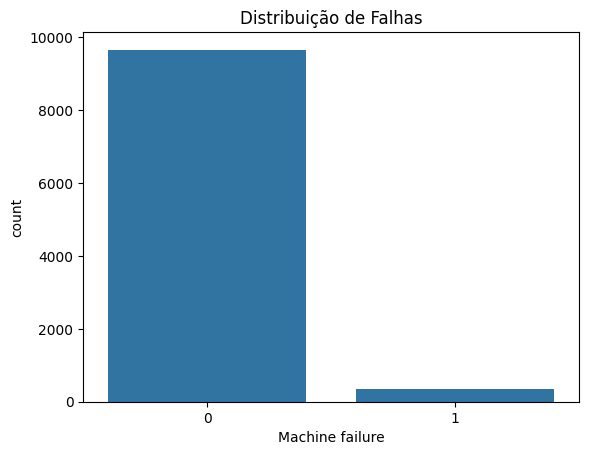

In [ ]:
df['Machine failure'].value_counts()

sns.countplot(x='Machine failure', data=df)
plt.title('Distribuição de Falhas')
plt.show()

*Carta de controle*

Foi construída uma carta de controle para a variável Torque, utilizando a média do processo e os limites de controle calculados a partir de três desvios padrão. O objetivo da carta de controle é monitorar a estabilidade do processo produtivo e identificar possíveis variações anormais nas condições operacionais da usinagem industrial.


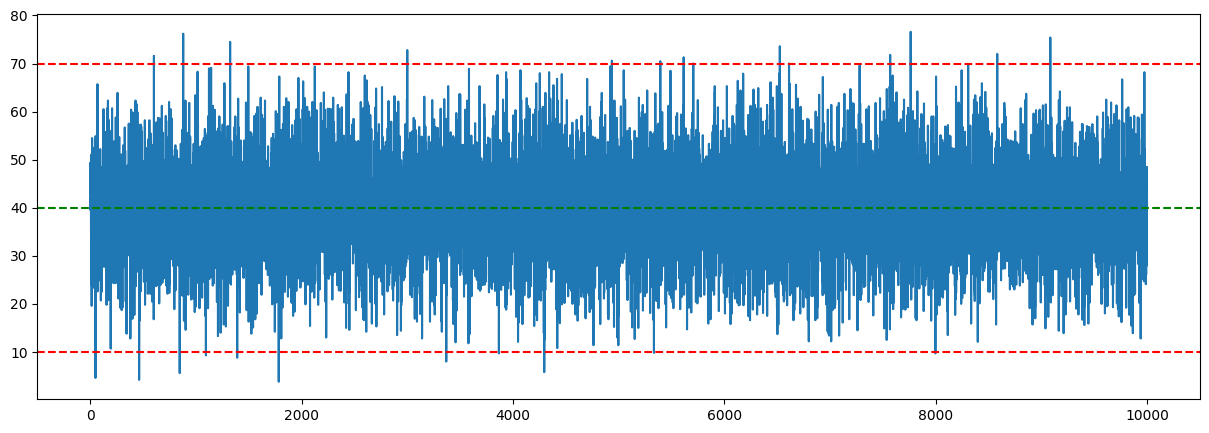

In [ ]:
media = df['Torque [Nm]'].mean()
desvio = df['Torque [Nm]'].std()

LSC = media + 3*desvio
LIC = media - 3*desvio


plt.figure(figsize=(15,5))
plt.plot(df['Torque [Nm]'])
plt.axhline(media, color='green', linestyle='--')
plt.axhline(LSC, color='red', linestyle='--')
plt.axhline(LIC, color='red', linestyle='--')
plt.show()

*Fazendo o heatmap de correlação*

Foi elaborada uma matriz de correlação entre as variáveis numéricas do processo produtivo. O objetivo foi identificar relações entre as variáveis operacionais e possíveis associações com as falhas da máquina.


<Axes: >

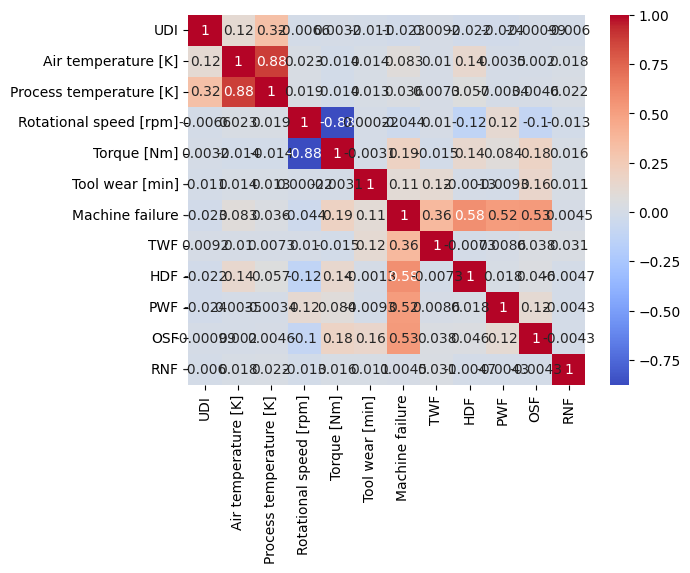

In [ ]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

*Machine Learning*

Foram selecionadas as principais variáveis operacionais do processo produtivo como entradas do modelo preditivo, enquanto a variável "Machine failure" foi utilizada como variável alvo para classificação das falhas.


In [ ]:
X = df[['Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]']]

y = df['Machine failure']

*Separando treino e teste*

A base de dados foi dividida em conjuntos de treino e teste, permitindo avaliar o desempenho do modelo de ML em dados não utilizados durante o treinamento.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

*Treinando e fazendo a previsão do modelo*

Foi utilizado o algoritmo Random Forest para treinamento do modelo preditivo de falhas. O modelo foi treinado utilizando as variáveis operacionais do processo industrial.

Após o treinamento, o modelo realizou previsões utilizando os dados de teste, permitindo avaliar sua capacidade de identificar falhas no processo produtivo.


In [ ]:
modelo = RandomForestClassifier(random_state=42)

modelo.fit(X_train, y_train)

pred = modelo.predict(X_test)

*Avaliando o modelo*

O desempenho do modelo foi avaliado por meio da matriz de confusão e das métricas de classificação. Essas métricas permitem analisar a capacidade do modelo em identificar corretamente situações de falha e não falha no processo industrial.


In [ ]:
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[2900    7]
 [  32   61]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2907
           1       0.90      0.66      0.76        93

    accuracy                           0.99      3000
   macro avg       0.94      0.83      0.88      3000
weighted avg       0.99      0.99      0.99      3000



Os testes iniciais realizados demonstraram a viabilidade da aplicação de técnicas de Controle Estatístico de Processos (CEP) e Machine Learning no monitoramento de um processo industrial de usinagem. A análise exploratória dos dados e as estatísticas descritivas permitiram compreender o comportamento das variáveis operacionais, enquanto a carta de controle possibilitou avaliar a estabilidade do processo e identificar possíveis variações relevantes nas condições de operação.

Além disso, foi desenvolvido um modelo inicial de ML utilizando o algoritmo Random Forest para classificação de falhas da máquina. Os resultados obtidos indicaram potencial para aplicação preditiva no contexto industrial, mostrando que a integração entre CEP e aprendizado de máquina pode contribuir para o monitoramento da qualidade e apoio à tomada de decisão.

Nas próximas etapas, o projeto será aprofundado com análises mais avançadas e aprimoramento dos modelos utilizados.